In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_solve
import scipy.optimize as opt
import random
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib
from scipy.linalg import cho_solve
from scipy.optimize import fmin_cobyla
from eos_code import *

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
data = np.loadtxt('data.txt')
degree = 3

In [3]:
n_test = 50
constraints=1

In [4]:
# Experimental data

V_exp = np.array([4.20714967, 3.45613335, 3.98837788])
T_exp = np.array([1677.4818324 , 6191.47299911, 2373.53608845])

X_exp = np.hstack((V_exp.reshape(-1,1), T_exp.reshape(-1,1)))
y_exp = np.array([265, 599, 316]).reshape(-1,1)

In [5]:
X1 = np.vstack((data[:,0:2], X_exp))
X2 = data[:,0:2]
y1 = np.vstack((data[:,2].reshape(-1,1), y_exp))    # pressure
y2 = data[:,3].reshape(-1,1)                        # energy



In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X1)
X_P = scaler.transform(X1)
X_E = scaler.transform(X2)


scaler1 = MinMaxScaler()
y_P = scaler1.fit_transform(y1)
scaler2 = MinMaxScaler()

y_E = scaler2.fit_transform(y2)
y = np.concatenate((y_P, y_E))
y = y.reshape(-1,1)

In [7]:
X_test,_ = test(X_P, n_test = 50)               # test points
X_c,_  = test(X_P, n_test = 10)                   # virtual points

In [8]:
mu_regression, mu_test_regression = poly_regression_unified(X_P, X_E, y, X_test, degree)

In [9]:
mu_virtual_regression = poly_regression_prime_unified(X_P, X_E,y, X_test, degree=3)

In [10]:

class GP_EOS:
    def __init__(self, X_P, X_E, y, mu_regression, X_c, n_test, degree):
        self.X_P = X_P
        self.X_E = X_E
        self.y = y
        self.mu_regression = mu_regression
        self.X_c = X_c
        self.n_test = n_test
        self.degree = degree

    def neglikelihood(self, theta):
        return mle_unified(theta, self.X_P, self.X_E, self.y, self.mu_regression)

    def predict_virtual(self, theta):
        return predict_prime_unified(theta, self.X_P, self.X_E, self.y, self.X_c, self.n_test, self.degree, constraints=1)

    def nonneg_const(self, theta):
        yy, s = self.predict_virtual(theta)
        y_prime_mean_P = yy[:self.X_c.shape[0]]
        y_prime_std_P = s[:self.X_c.shape[0]]

        y_prime_mean_E = yy[self.X_c.shape[0]:]
        y_prime_std_E = s[self.X_c.shape[0]:]

        const1 = y_prime_mean_P + 1.96 * np.sqrt(y_prime_std_P)
        const2 = y_prime_mean_E - 1.96 * np.sqrt(y_prime_std_E)

        const = np.concatenate((-const1, const2))

        return const

    def opti(self):
        n = 10
        lb = np.array([-2.0, -2.0, -2.0, -10.0, -10.0])
        r = np.random.standard_normal(size=(n, 5))
        x0 = r + lb
        optipar = np.zeros((n, 5))
        optifun = np.zeros((n, 1))

        for i in range(n):
            print(i)
            res = fmin_cobyla(self.neglikelihood, x0[i, :].T, self.nonneg_const, args=(),
                              consargs=None, rhobeg=1.0, rhoend=0.0001, maxfun=1000,
                              disp=True, catol=0.0002)
            optipar[i, :] = res
            print(optipar[i, :])
            optifun[i, :] = self.neglikelihood(res)
            print(optifun[i, :])

        theta = optipar[np.argmin(optifun)]

        return theta


In [11]:
optimizer = GP_EOS(X_P, X_E, y, mu_regression, X_c, n_test, degree)
thetaopt = optimizer.opti()


0
[-0.9778132  -1.17890784 -3.28626482 -9.59674714 -9.81384462]
   Normal return from subroutine COBYLA

   NFVALS =  102   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.778132E-01  -1.178908E+00  -3.286265E+00  -9.596747E+00  -9.813845E+00

[-178.232892]
1
[ -0.97811192  -1.17896207  -3.28637272 -10.6372413   -9.30975569]
   Normal return from subroutine COBYLA

   NFVALS =  143   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.781119E-01  -1.178962E+00  -3.286373E+00  -1.063724E+01  -9.309756E+00

[-178.2328898]
2
[-0.97789612 -1.17884777 -3.28614711 -8.93279849 -8.82218408]
   Normal return from subroutine COBYLA

   NFVALS =  123   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.778961E-01  -1.178848E+00  -3.286147E+00  -8.932798E+00  -8.822184E+00

[-178.2328932]
3
[ -0.97806404  -1.17890691  -3.28626408 -11.20480116 -11.09251531]
   Normal return from subroutine COBYLA

   NFVALS =  105   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.780640E-01  -1.178907E+00  -3.2862

In [13]:
y_pred, y_std = predict_unified(thetaopt, X_P, X_E, y, X_test, n_test, degree, constraints)
X_testP, X_testE = test(X_P, n_test=50)          # test points

In [15]:
y_pred_P_prime, y_varr_P_prime = predict_prime_unified(thetaopt, X_P, X_E, y, X_testP,n_test, degree, constraints=1)
y_pred_E_prime, y_varr_E_prime = predict_prime_unified(thetaopt, X_P, X_E, y, X_testE,n_test, degree, constraints=1)

In [16]:
consP = y_pred_P_prime[:X_testP.shape[0]] + 1.96*np.sqrt(y_varr_P_prime[:X_testP.shape[0]])
consE = y_pred_E_prime[X_testE.shape[0]:] - 1.96*np.sqrt(y_varr_E_prime[X_testE.shape[0]:])
consP[consP>0].size, consE[consE<0].size

(0, 0)

In [17]:
y11 = y_pred[:X_test.shape[0]].reshape(-1,1)
y22 = y_pred[X_test.shape[0]:].reshape(-1,1)
y33 = y_std[:X_test.shape[0]].reshape(-1,1)
y44 = y_std[X_test.shape[0]:].reshape(-1,1)

In [18]:

P_mean = scaler1.inverse_transform(y11)
E_mean = scaler2.inverse_transform(y22)
P_ub = scaler1.inverse_transform(y11+y33)
E_ub = scaler2.inverse_transform(y22+y44)

In [19]:
P_std = P_ub - P_mean
E_std = E_ub - E_mean

In [20]:
meanP = P_mean
meanE = E_mean
stdP =  P_std
stdE =  E_std

In [21]:
X_testP = scaler.inverse_transform(X_testP)
X_testE = scaler.inverse_transform(X_testE)

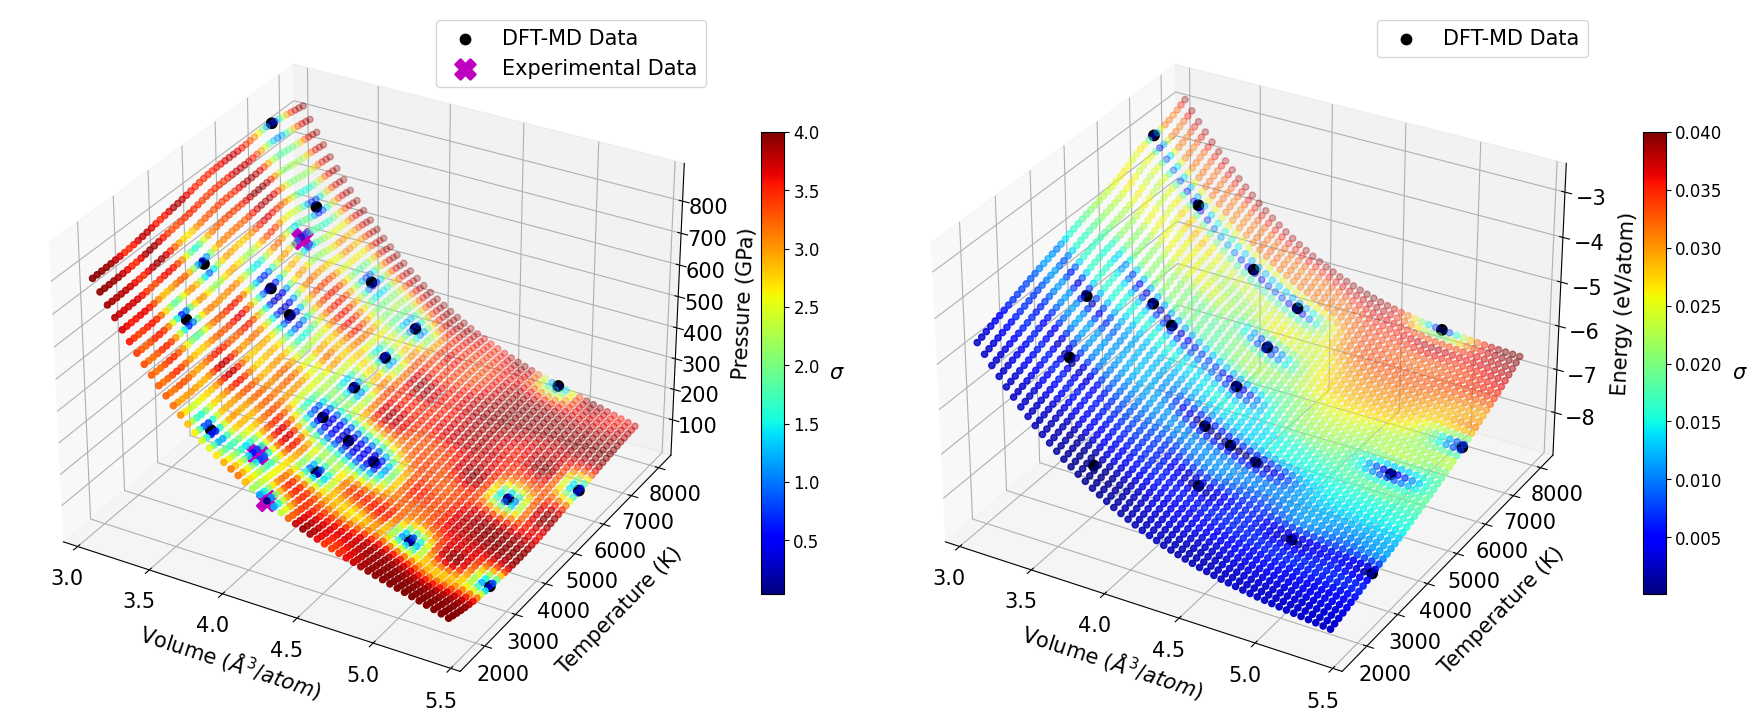

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(121, projection='3d')
p1 = ax1.scatter(data[:, 0], data[:, 1], data[:, 2], alpha=1, marker="o", color="k", linewidths=4, label="Simulation Data")
p2 = ax1.scatter(X_exp[:, 0], X_exp[:, 1], y_exp, alpha=1, marker="X", color="m", s=200, linewidths=2, label="Experimental Data")
p0 = ax1.scatter(X_testP[:, 0], X_testP[:, 1], meanP, c=stdP, cmap=plt.cm.jet, vmax=4)
ax1.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=15, labelpad=8)
ax1.set_ylabel('Temperature (K)', fontsize=15, labelpad=12)
ax1.set_zlabel('Pressure (GPa)', fontsize=15, labelpad=9)
ax1.legend(['DFT-MD Data', 'Experimental Data'], loc='upper right', fontsize=15)
cbar1 = fig.colorbar(p0, ax=ax1, shrink=0.6)
cbar1.set_label(r'$\sigma$', rotation=0, fontsize=15, labelpad=12)
cbar1.ax.tick_params(labelsize=12)

ax2 = fig.add_subplot(122, projection='3d')
p = ax2.scatter(data[:, 0], data[:, 1], y2, alpha=1, marker="o", color="k", linewidths=4, label="Data")
p0 = ax2.scatter(X_testP[:, 0], X_testP[:, 1], meanE, c=stdE, cmap=plt.cm.jet, vmax=0.04)
ax2.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=15, labelpad=8)
ax2.set_ylabel('Temperature (K)', fontsize=15, labelpad=12)
ax2.set_zlabel('Energy (eV/atom)', fontsize=15, labelpad=8)
ax2.legend(['DFT-MD Data'], loc='upper right', fontsize=15)
cbar2 = fig.colorbar(p0, ax=ax2, shrink=0.6)
cbar2.set_label(r'$\sigma$', rotation=0, fontsize=15, labelpad=12)
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


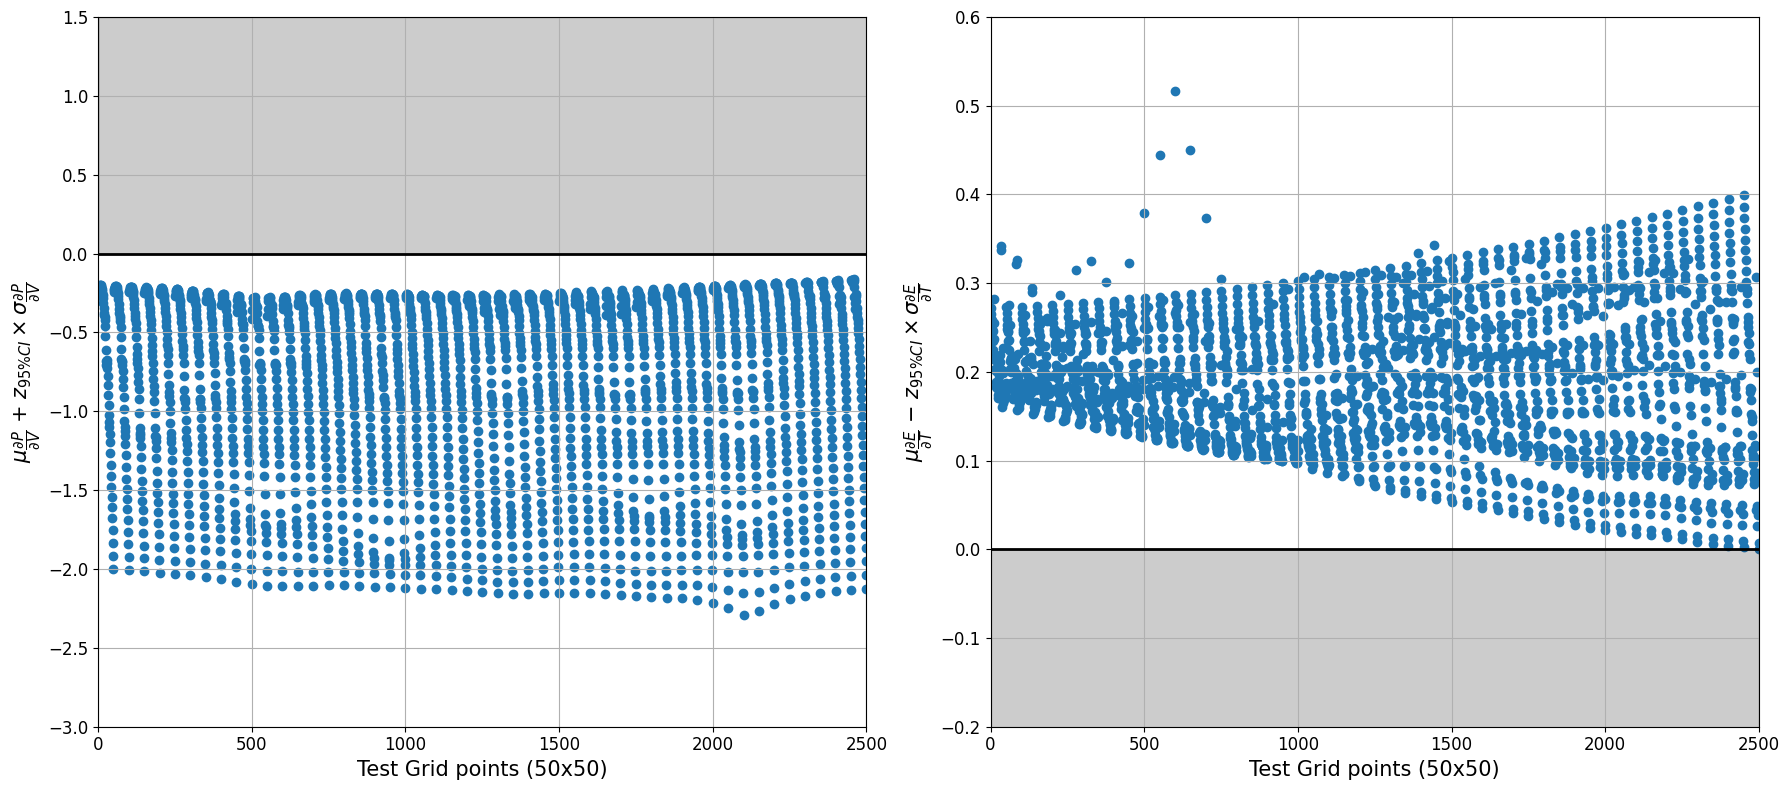

In [29]:
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(1,2500,2500, dtype=int)
plt.figure(figsize=(18, 8))

plt.subplot(121)
plt.scatter(t, consP)
plt.axhline(y=0, color='k', linewidth=2)
plt.ylabel(r'$\mu_{\dfrac{\partial P}{\partial V}}$ $+$ $z_{95\% CI} \times \sigma_{\dfrac{\partial P}{\partial V}}$', fontsize=15)
plt.xlabel('Test Grid points (50x50)', fontsize=15)
plt.xlim((0, 2500))
plt.ylim((-3, 1.5))
plt.tick_params(labelsize=12)
plt.fill_between(t, y1=0, y2=1.5, color='black', alpha=0.2)
plt.grid()

 
plt.subplot(122)
plt.scatter(t, consE)
plt.axhline(y=0, color='k', linewidth=2)
plt.ylabel(r'$\mu_{\dfrac{\partial E}{\partial T}}$ $-$ $z_{95\% CI} \times \sigma_{\dfrac{\partial E}{\partial T}}$', fontsize=15)
plt.xlabel('Test Grid points (50x50)', fontsize=15)
plt.xlim((0, 2500))
plt.ylim((-0.20, 0.6))
plt.tick_params(labelsize=12)
plt.fill_between(t, y1=0, y2=-0.6, color='black', alpha=0.2)
plt.grid()

plt.tight_layout()
plt.show()
